In this notebook, we will use sklearn's LASSO for feature selection. This serves to simplify our dataset and improve interpretability.

In [1]:
#dependencies
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
#for feature selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [ ]:
# download LightGBM package
!pip install lightgbm

In [25]:
# LGBM dependencies
import lightgbm as lgbm
#from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
# function for model evalaution in both log-price 'units' as well as natural units (USD dollar) 
def evaluate_model(y_true, y_pred_log):

    # TRUE VALUES IN LOG SPACE
    y_true_log = np.log1p(y_true)

    # BACK TRANSFORM PREDICTIONS
    y_pred = np.expm1(y_pred_log)

    # --- METRICS IN LOG SPACE ---
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    r2_log = r2_score(y_true_log, y_pred_log)
    mape_log = mean_absolute_percentage_error(y_true_log, y_pred_log)

    # --- METRICS IN PRICE SPACE ---
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)

    print("------ LOG METRICS ------")
    print("RMSE_log:", rmse_log)
    print("MAE_log:", mae_log)
    print("R2_log:", r2_log)
    print("MAPE_log:", mape_log)

    print("\n------ PRICE METRICS ($) ------")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)
    print("MAPE:", mape)

    return

In [29]:
#train = pd.read_csv(r"C:\Users\Sean\Documents\GitHub\spring-2026-valuation-of-stringed-instruments-II\train.csv")
#val = pd.read_csv(r"C:\Users\Sean\Documents\GitHub\spring-2026-valuation-of-stringed-instruments-II\train.csv")
train = pd.read_csv("train.csv")
val = pd.read_csv("val.csv")

#drop unnecessary features
UnneededFeatures = ['sale_date.1', 'maker_name_maker', 'is_ambiguous', 'candidate_count', 'location_filled', 'date', 'usd', 'gbp', 'eur']
train = train.drop(columns = UnneededFeatures)
valid = val.drop(columns = UnneededFeatures)

X_train = train.iloc[:, train.columns != 'price_usd_real']
X_valid = valid.iloc[:, train.columns != 'price_usd_real']
Y_train = train.iloc[:, train.columns == 'price_usd_real']
Y_valid = valid.iloc[:, train.columns == 'price_usd_real']


#collect categorical features
#CategoricalCols = train.select_dtypes(include=["object", "str", "bool"]).columns.tolist()
CategoricalCols = train.select_dtypes(include=["object", "bool"]).columns.tolist()

for x in CategoricalCols:
    print(f"{x} has {train[x].nunique()} unique values")



sale_date has 941 unique values
maker_name has 3060 unique values
type has 14 unique values
city_maker has 628 unique values
auction_house has 27 unique values
lot has 1244 unique values
bold_currency has 3 unique values
country_iso1 has 37 unique values
admin1_name has 164 unique values
admin2_name has 371 unique values
role has 34 unique values
maker_last_name has 2164 unique values


We will consider features with less that 20 unique values as "low cardinality", and the rest as "high cardinality".

In [30]:
LowCardCols = ["type", "bold_currency"]
HighCardCols = ["sale_date", "maker_name", "city_maker", "auction_house", "lot", "country_iso1", "admin1_name", "admin2_name", "role", "maker_last_name"]

In [31]:
#log transforming economic features
LogColumns = ['real_price_gold', 'SP500_real']

In [32]:
#features with numerical values
numberdtype = X_train.select_dtypes(include=[np.number]).columns.tolist()

#prevent overlap
NumericalCols = list( set(numberdtype) - set(LogColumns))


In [33]:
#impute with median and scale numerical columns
Numerical_transformer = Pipeline([
     ('imputer', SimpleImputer(strategy='median')), 
     ('scaler', StandardScaler() )
     ])

#impute and one hot encode low cardinality columns
OneHot_transformer = Pipeline([
('imputer', SimpleImputer(strategy='constant', fill_value="other" )),
('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

#impute and target encode high cardinality columns
Target_transformer = Pipeline([
('imputer', SimpleImputer(strategy='constant', fill_value="other")),
('target', TargetEncoder() )
])

#transform "log columns"
log_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p, feature_names_out="one-to-one") ),
    ('scale', StandardScaler())
])



In [34]:
#this will apply our transformations
preprocessor = ColumnTransformer(
    transformers =[
        ('lognum', log_transformer, LogColumns),
        ('lowcard', OneHot_transformer, LowCardCols ),
        ('highcard', Target_transformer, HighCardCols ) ,
        ('num', Numerical_transformer, NumericalCols )],
        remainder = 'passthrough',
        sparse_threshold=0
)




In [35]:
#creates a pipeline object
pipeline_randomforest = Pipeline([
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=0))
])



In [11]:
#fits our data to the pipeline/model with log transformed target
rf = pipeline_randomforest.fit(X_train,np.log1p(Y_train))

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [14]:
#converting predictions back to USD
forest_pred = np.expm1(rf.predict(X_valid))

rmse = mean_squared_error(Y_valid, forest_pred)
r2 = r2_score(Y_valid, forest_pred)
mae = mean_absolute_error(Y_valid, forest_pred)

print("RMSE:", rmse)
print("R^2:", r2)
print("mae:", mae)



RMSE: 13099438297.958015
R^2: 0.5920659932219328
mae: 7833.409074355258


In [12]:
#converting predictions back to USD - with real Val
forest_pred = np.expm1(rf.predict(X_valid))

rmse = mean_squared_error(Y_valid, forest_pred)
r2 = r2_score(Y_valid, forest_pred)
mae = mean_absolute_error(Y_valid, forest_pred)

print("RMSE:", rmse)
print("R^2:", r2)
print("mae:", mae)



RMSE: 5533060999.053009
R^2: 0.6462390584584762
mae: 11827.65896005982


We can fit our data to a lasso regression pipeline with the same transformed columns. We can use this with the goal of feature selection and determining feature importance.

In [10]:
#lassocv with 10 cross validation folds
pipeline_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', LassoCV(cv=10))
])


lr = pipeline_lasso.fit(X_train,np.log1p(Y_train))



/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:1714: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [11]:
#predictions in log prices
lasso_pred = lr.predict(X_valid)

#errors in log prices
rmse = mean_squared_error(np.log1p(Y_valid), lasso_pred)
r2 = r2_score(np.log1p(Y_valid), lasso_pred)
mae = mean_absolute_error(np.log1p(Y_valid), lasso_pred)

print("RMSE:", rmse)
print("R^2:", r2)
print("mae:", mae)

#gives the optimal penalty determined by lassocv
optimal_alpha = pipeline_lasso.named_steps['lasso'].alpha_
print("Optimal alpha:", f"{optimal_alpha:.5f}")


RMSE: 0.43360356570867453
R^2: 0.763837070469346
mae: 0.5018859973310208
Optimal alpha: 0.00125


In [12]:
#predictions in log prices
lasso_pred = lr.predict(X_valid)

#errors in log prices
rmse = mean_squared_error(np.log1p(Y_valid), lasso_pred)
r2 = r2_score(np.log1p(Y_valid), lasso_pred)
mae = mean_absolute_error(np.log1p(Y_valid), lasso_pred)

print("RMSE:", rmse)
print("R^2:", r2)
print("mae:", mae)

#gives the optimal penalty determined by lassocv
optimal_alpha = pipeline_lasso.named_steps['lasso'].alpha_
print("Optimal alpha:", f"{optimal_alpha:.5f}")


RMSE: 0.43360356570867453
R^2: 0.763837070469346
mae: 0.5018859973310208
Optimal alpha: 0.00125


In [13]:
#prediction in USD
lasso_pred_dollars = np.expm1(lasso_pred)

#mape and mae instead of r^2 and rmse
mape = mean_absolute_percentage_error(Y_valid, lasso_pred_dollars)
mae = mean_absolute_error(Y_valid, lasso_pred_dollars)
print("mape:", mape)
print("mae:", mae)

mape: 0.6499796808805286
mae: 14014.358226876939


In [14]:
#recovers the features transformed in the pipeline
preprocessor_lasso = pipeline_lasso.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

In [15]:
#gives coefficients used for each feature in regression
lasso_step = lr.named_steps['lasso']
coefficients = lasso_step.coef_

zerofeatures = []
nonzerofeatures = []

#setting a lower bound for a coefficient to be considered "nonzero"
epsilon = 1e-5

for i in range(len(feature_names)):
    if abs(coefficients[i]) < epsilon:
        zerofeatures.append(feature_names[i])
    else: nonzerofeatures.append(feature_names[i])

#the features with a coefficient of zero
for x in zerofeatures:
    print(x)


lowcard__type_Bass
lowcard__type_Bass Bow
lowcard__type_Bass Viol
lowcard__type_Miscellaneous
lowcard__type_Tenor Viol
lowcard__type_Treble Viol
lowcard__type_Viola Bow
lowcard__type_Viola d'Amore
lowcard__bold_currency_usd
num__gbp_usd_x
num__SP500_trend_ratio
num__SP500_vol_30d
num__Year
num__cpi_usd
num__SP500_ma200
num__gbp_vol_30d


In [16]:
#prints each feature and its corresponding coefficient
feature_and_coeff = []
for i in range(len(feature_names)):
    feature_and_coeff.append( ( feature_names[i], coefficients[i] ))
for x in feature_and_coeff:
    print(x)

('lognum__real_price_gold', np.float64(-0.01955436851587931))
('lognum__SP500_real', np.float64(0.0001888440790231773))
('lowcard__type_Bass', np.float64(0.0))
('lowcard__type_Bass Bow', np.float64(-0.0))
('lowcard__type_Bass Viol', np.float64(0.0))
('lowcard__type_Cello', np.float64(0.809252736738935))
('lowcard__type_Cello Bow', np.float64(-0.04493967603268421))
('lowcard__type_Miscellaneous', np.float64(0.0))
('lowcard__type_Small Violin', np.float64(-0.2795693366912031))
('lowcard__type_Tenor Viol', np.float64(0.0))
('lowcard__type_Treble Viol', np.float64(-0.0))
('lowcard__type_Viola', np.float64(0.054384103699814716))
('lowcard__type_Viola Bow', np.float64(-0.0))
("lowcard__type_Viola d'Amore", np.float64(-0.0))
('lowcard__type_Violin', np.float64(0.011375112370280651))
('lowcard__type_Violin Bow', np.float64(-0.14472473050391896))
('lowcard__bold_currency_eur', np.float64(-0.014184392932790274))
('lowcard__bold_currency_gbp', np.float64(0.02177409996178721))
('lowcard__bold_curr

In [17]:
#shows the different alphas selected by lassocv
alphas =lasso_step.alphas_
print(alphas)


[1.24951456 1.16530146 1.08676404 1.01351978 0.94521194 0.88150782
 0.82209714 0.76669055 0.71501817 0.66682834 0.62188634 0.57997328
 0.54088503 0.50443119 0.47043421 0.43872852 0.40915969 0.38158369
 0.35586623 0.33188204 0.3095143  0.28865407 0.26919975 0.25105659
 0.23413622 0.21835622 0.20363974 0.1899151  0.17711546 0.16517847
 0.154046   0.14366381 0.13398135 0.12495146 0.11653015 0.1086764
 0.10135198 0.09452119 0.08815078 0.08220971 0.07666905 0.07150182
 0.06668283 0.06218863 0.05799733 0.0540885  0.05044312 0.04704342
 0.04387285 0.04091597 0.03815837 0.03558662 0.0331882  0.03095143
 0.02886541 0.02691998 0.02510566 0.02341362 0.02183562 0.02036397
 0.01899151 0.01771155 0.01651785 0.0154046  0.01436638 0.01339814
 0.01249515 0.01165301 0.01086764 0.0101352  0.00945212 0.00881508
 0.00822097 0.00766691 0.00715018 0.00666828 0.00621886 0.00579973
 0.00540885 0.00504431 0.00470434 0.00438729 0.0040916  0.00381584
 0.00355866 0.00331882 0.00309514 0.00288654 0.002692   0.00251

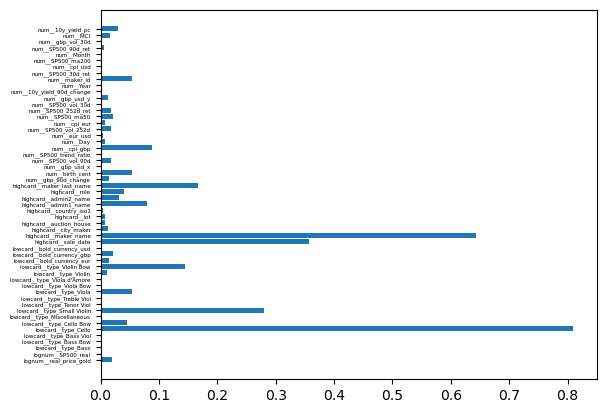

<Figure size 1200x600 with 0 Axes>

In [18]:


abs_coefficients = [abs(x) for x in coefficients]
plt.barh(feature_names, abs_coefficients)
plt.tight_layout
plt.yticks(fontsize=4)
plt.figure(figsize=(12,6))
plt.show()

Next I will drop some features which had a zero coefficient and run the random forest model again to see if there are any changes.

In [19]:
zerofeatures_extract = []
for x in zerofeatures:
    if "highcard" in x:
        zerofeatures_extract.append(x.split("_",2)[-1].strip("'\'"))
    elif "num" in x:
         zerofeatures_extract.append(x.split("_",2)[-1].strip("'\'"))
for x in zerofeatures_extract:
    print(x)

gbp_usd_x
SP500_trend_ratio
SP500_vol_30d
Year
cpi_usd
SP500_ma200
gbp_vol_30d


In [20]:
#preparing new train and validation sets
train_new = train.drop(columns = zerofeatures_extract)
valid_new = valid.drop(columns = zerofeatures_extract)

X_train_new = train_new.iloc[:, train_new.columns != 'price_usd_real']
X_valid_new = valid_new.iloc[:, train_new.columns != 'price_usd_real']
Y_train_new = train_new.iloc[:, train_new.columns == 'price_usd_real']
Y_valid_new = valid_new.iloc[:, train_new.columns == 'price_usd_real']




In [21]:
HighCardCols_new = ["sale_date", "maker_name", "auction_house", "lot", "country_iso1", "admin1_name", "admin2_name", "role", "maker_last_name"]

#new features with numerical values
numberdtype_new = X_train_new.select_dtypes(include=[np.number]).columns.tolist()

#prevent overlap
NumericalCols_new = list( set(numberdtype_new) - set(LogColumns))


In [22]:
preprocessor_new = ColumnTransformer(
    transformers =[
        ('lognum', log_transformer, LogColumns),
        ('lowcard', OneHot_transformer, LowCardCols ),
        ('highcard', Target_transformer, HighCardCols_new ) ,
        ('num', Numerical_transformer, NumericalCols_new )],
        remainder = 'passthrough',
        sparse_threshold=0
)

In [23]:
pipeline_randomforest_new = Pipeline([
    ('preprocessor', preprocessor_new),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=0))
])


In [108]:
rf_new = pipeline_randomforest_new.fit(X_train_new, np.log1p(Y_train_new))


In [109]:
#converting predictions back to USD
forest_pred_new = np.expm1(rf_new.predict(X_valid_new))

rmse = mean_squared_error(Y_valid_new, forest_pred_new)
r2 = r2_score(Y_valid_new, forest_pred_new)
mae = mean_absolute_error(Y_valid_new, forest_pred_new)

print("RMSE:", rmse)
print("R^2:", r2)
print("mae:", mae)


RMSE: 9799747089.63122
R^2: 0.6948227851641444
mae: 7706.118253213228


# New Model: LightGBM

Define the Model with default parameters.

In [49]:
lgbm_model = lgbm.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [50]:
pipeline_lgbm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgbm_model)])

Use cross-validation to find the best model via a grid-search.

In [76]:
'''param_grid = {
    "model__num_leaves": [80, 100, 120, 140],
    "model__learning_rate": [0.005, 0.007, 0.009],
    "model__n_estimators": [800, 900, 1000],
    "model__max_depth": [-1]
}'''
# this parameter grid has already been narrowed down in many iterations of running the algo
param_grid = {
    "model__num_leaves": [62, 63, 64],
    "model__learning_rate": [0.008, 0.009, 0.01, 0.011, 0.012],
    "model__n_estimators": [2300, 2500, 2700, 2900],
    "model__max_depth": [-1]
}


search = RandomizedSearchCV(
    pipeline_lgbm,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_iter=20,
    n_jobs=-1,
    verbose=1
)

In [77]:
search.fit(X_train, np.log1p(Y_train))

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002505 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7823
[LightGBM] [Info] Number of data points in the train set: 26897, number of used features: 48
[LightGBM] [Info] Start training from score 8.887658
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005700 seconds.
You can set `force_col_wise=true` to rem

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:140

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010048 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7829
[LightGBM] [Info] Number of data points in the train set: 26898, number of used features: 48
[LightGBM] [Info] Start training from score 8.885218
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

...

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006280 seco

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7832
[LightGBM] [Info] Number of data points in the train set: 33622, number of used features: 49
[LightGBM] [Info] Start training from score 8.887616


,estimator,Pipeline(step...sample=0.8))])
,param_distributions,"{'model__colsample_bytree': [0.7, 0.8, ...], 'model__max_depth': [-1, 8, ...], 'model__min_child_samples': [10, 20, ...], 'model__num_leaves': [31, 63, ...], ...}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [ ]:
best_model = search.best_estimator_
print(search.best_params_)

In [ ]:
best_model = search.best_estimator_
print(search.best_params_)

{'model__num_leaves': 63, 'model__n_estimators': 2000, 'model__max_depth': -1, 'model__learning_rate': 0.01}


In [22]:
best_model = search.best_estimator_
print(search.best_params_)

{'model__num_leaves': 63, 'model__n_estimators': 2000, 'model__max_depth': -1, 'model__learning_rate': 0.01}


In [22]:
best_model = search.best_estimator_
print(search.best_params_)

{'model__num_leaves': 63, 'model__n_estimators': 2000, 'model__max_depth': -1, 'model__learning_rate': 0.01}


### Prediction

In [81]:
y_pred_log_lgbm = best_model.predict(X_valid)
#y_pred_lgbm = np.expm1(y_pred_log_lgbm)

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### Comparison of LGBM with Lasso

In [30]:
evaluate_model(Y_valid, lasso_pred)

------ LOG METRICS ------
RMSE_log: 0.6583203209455881
MAE_log: 0.5015586473374233
R2_log: 0.763955761375381
MAPE_log: 0.05819422437252197

------ PRICE METRICS ($) ------
RMSE: 99241.36399747196
MAE: 13997.62558563378
R2: 0.37030554005511473
MAPE: 0.6496506221107488


In [32]:
evaluate_model(Y_valid, y_pred_log_lgbm)

------ LOG METRICS ------
RMSE_log: 0.5906034083811118
MAE_log: 0.44837021125667825
R2_log: 0.8100187326696261
MAPE_log: 0.05215482028466904

------ PRICE METRICS ($) ------
RMSE: 77905.38191595816
MAE: 11613.068339238063
R2: 0.6119574544162316
MAPE: 0.5637232715809534

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

In [73]:
evaluate_model(Y_valid, y_pred_log_lgbm)

------ LOG METRICS ------
RMSE_log: 0.5921840487635375
MAE_log: 0.4501726829078604
R2_log: 0.809000472711218
MAPE_log: 0.05234187094218224

------ PRICE METRICS ($) ------
RMSE: 80199.39676681226
MAE: 11722.432838463146
R2: 0.5887682609072453
MAPE: 0.5657360454547681
